# Time Series Analysis of COVID-19 Vaccinations
This notebook performs **time series analysis** on the dataset `cleaned_vaccinations.csv`.
We will:
1. Load and preprocess the dataset
2. Filter data for a specific country (India)
3. Visualize vaccination trends over time
4. Apply rolling average smoothing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Load dataset
file_path = r'cleaned_vaccinations.csv'
df = pd.read_csv(file_path)

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])
df.head()

,location,date,total_vaccinations_per_hundred,total_vaccinations,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,daily_vaccinations_per_million,daily_people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred.1
0,Afghanistan,2021-05-11,1.23,504502.0,1.09,0.14,0.0,338.0,0.027,0.14
1,Afghanistan,2021-05-20,1.33,547901.0,1.14,0.19,0.0,117.0,0.006,0.19
2,Afghanistan,2021-05-24,1.39,573277.0,1.16,0.24,0.0,138.0,0.005,0.24
3,Afghanistan,2021-05-26,1.44,590454.0,1.17,0.27,0.0,165.0,0.004,0.27
4,Afghanistan,2021-05-27,1.44,593313.0,1.17,0.28,0.0,158.0,0.003,0.28


In [2]:
# Filter data for India
india_df = df[df['location'] == 'India'].copy()
india_df.set_index('date', inplace=True)
india_df = india_df.sort_index()
india_df[['total_vaccinations_per_hundred', 'daily_vaccinations_per_million']].head()

,total_vaccinations_per_hundred,daily_vaccinations_per_million
date,,
2021-02-13,0.57,230.0
2021-02-15,0.60,228.0
2021-02-16,0.63,226.0
2021-02-17,0.65,219.0
2021-02-18,0.69,236.0


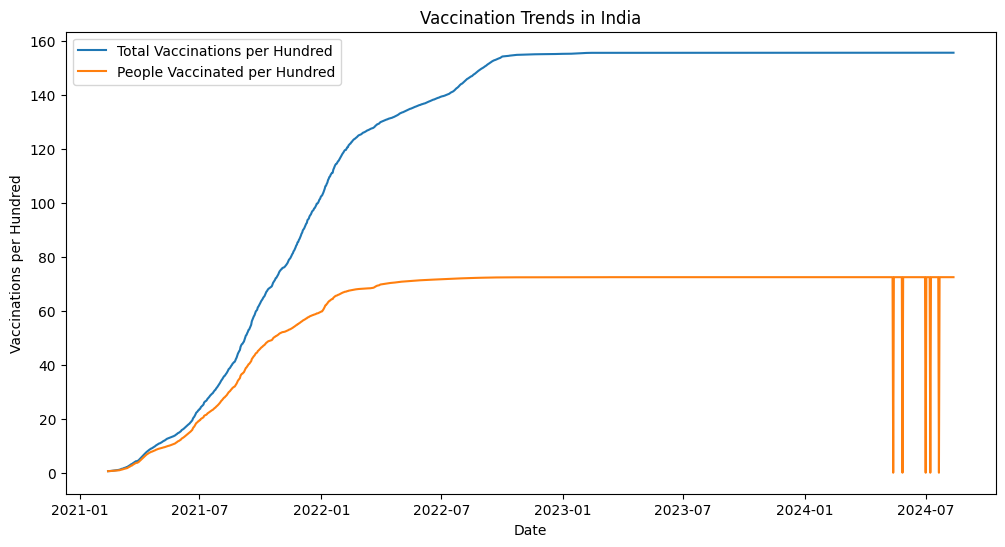

In [3]:
# Plot vaccination trends
plt.figure(figsize=(12,6))
sns.lineplot(x=india_df.index, y=india_df['total_vaccinations_per_hundred'], label='Total Vaccinations per Hundred')
sns.lineplot(x=india_df.index, y=india_df['people_vaccinated_per_hundred'], label='People Vaccinated per Hundred')
plt.title('Vaccination Trends in India')
plt.xlabel('Date')
plt.ylabel('Vaccinations per Hundred')
plt.legend()
plt.show()

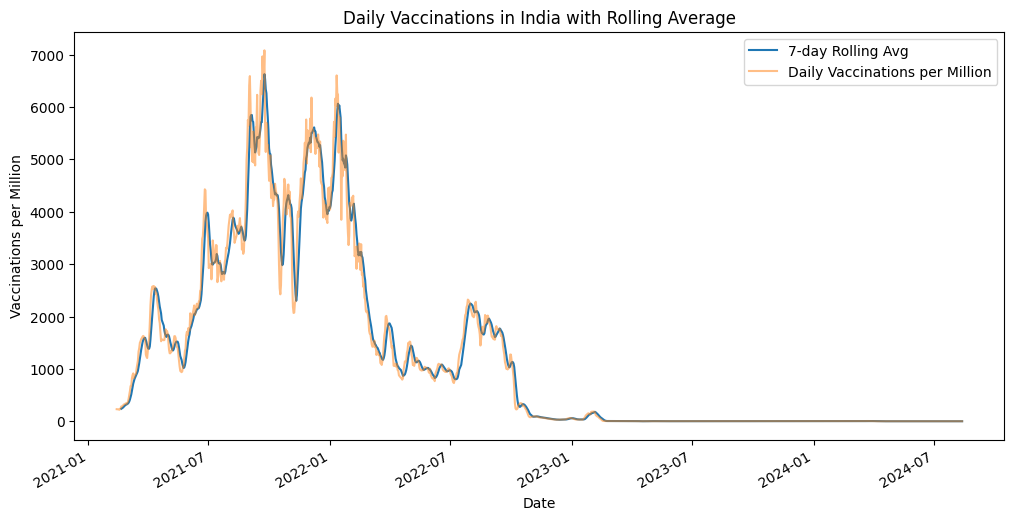

In [4]:
# Rolling average smoothing
plt.figure(figsize=(12,6))
india_df['daily_vaccinations_per_million'].rolling(window=7).mean().plot(label='7-day Rolling Avg')
india_df['daily_vaccinations_per_million'].plot(alpha=0.5, label='Daily Vaccinations per Million')
plt.title('Daily Vaccinations in India with Rolling Average')
plt.xlabel('Date')
plt.ylabel('Vaccinations per Million')
plt.legend()
plt.show()